In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB

In [2]:
#1 --- 1. Load the Dataset ---# 
ns_hra = pd.read_csv('c:\\Users\\s2421127\\Documents\\NLP Project\\ObuayaO\\NLP project\\Chapter 3\\ns_hra.csv', encoding='unicode_escape')
ns_hra['concat_corpus'] = ns_hra['Title']+ " " + ns_hra['Objective'] + " " + ns_hra['1ry_endpoint'] 
ns_hra['concat_corpus'] = ns_hra['concat_corpus'].fillna('')
X_corpus = ns_hra['concat_corpus']

In [3]:
# --- 2. Define the Manual Annotation Function --- #
def manually_label_samples(selected_rows):
    """
    Prompts the user to manually label the provided rows of data.
    Includes input validation.
    """
    labels = []
    for idx, row in selected_rows.iterrows():
        print("\n--- Please Label the Following Sample ---")
        print(f"Unique_ID: {row['Unique_ID']}")
        print(f"Text: {row['concat_corpus']}\n")
        
        # Prompt user for label until valid input is received
        while True:
            try:
                label_input = input("Enter label (0=Patient-Final, 1=Intermediate, 2=Surrogate): ")
                label = int(label_input)
                if label not in [0, 1, 2]:
                    print("Invalid input. Please enter 0, 1, or 2.")
                    continue
                labels.append(label)
                break
            except ValueError:
                print("Invalid input. Please enter a number (0, 1, or 2).")
    return labels


# --- 3. Setup for Live Annotation ---

# File to save progress
LABEL_LOG_FILE = 'label_log.csv'
N_ITERATIONS = 140 # Total number of samples you want to label

# --- 4. Load Progress or Initialise ---

labelled_data = []
if os.path.exists(LABEL_LOG_FILE):
    print(f"Loading previously labelled data from '{LABEL_LOG_FILE}'...")
    labelled_df = pd.read_csv(LABEL_LOG_FILE)
    labelled_data = labelled_df.to_dict('records')
    print(f"Loaded {len(labelled_data)} labeled samples.")
else:
    print("No previous session found. Starting a new annotation session.")

# Get indices of already labeled data
labelled_indices = {item['index'] for item in labelled_data}
all_indices = set(range(len(ns_hra)))
unlabelled_pool_indices = list(all_indices - labelled_indices)


# --- 5. Active Learning with Live Annotation ---

print(f"Goal is to label a total of {N_ITERATIONS} samples.")

while len(labelled_data) < N_ITERATIONS:
    current_progress = len(labelled_data)
    print(f"\n--- Annotation {current_progress + 1}/{N_ITERATIONS} ---")

    # Need at least a few labeled samples to start training a model.
    # We will pick randomly until we have at least 5.
    if current_progress < 5:
        print("Model requires more data. Selecting a sample at random.")
        if not unlabelled_pool_indices: break
        selected_idx = np.random.choice(unlabelled_pool_indices)
    else:
        # --- Train Model on Currently Labeled Data ---
        current_train_df = pd.DataFrame(labelled_data)
        X_train = X_corpus.iloc[current_train_df['index']]
        y_train = current_train_df['label']

        if len(y_train.unique()) < 2:
            print("Not enough class diversity yet. Selecting a sample at random.")
            if not unlabelled_pool_indices: break
            selected_idx = np.random.choice(unlabelled_pool_indices)
        else:
            print("Training model to find the most uncertain sample...")
            pipeline = make_pipeline(
                TfidfVectorizer(analyzer='word', min_df=2, ngram_range=(1, 3)),
                ComplementNB(alpha=0.1, fit_prior=True)
            )
            pipeline.fit(X_train, y_train)

            # --- Find Most Uncertain Sample ---
            X_unlabelled = X_corpus.iloc[unlabelled_pool_indices]
            probs = pipeline.predict_proba(X_unlabelled)
            least_confidence_scores = 1 - np.max(probs, axis=1)
            most_uncertain_pool_idx = np.argmax(least_confidence_scores)
            selected_idx = unlabelled_pool_indices[most_uncertain_pool_idx]

    # --- Call the Manual Annotation Function ---
    # Create a DataFrame with the single selected row to pass to the function
    row_to_label = ns_hra.iloc[[selected_idx]]
    
    # Get the label. Since batch size is 1, it returns a list with one item.
    new_labels = manually_label_samples(row_to_label)
    new_label = new_labels[0]
    
    # --- Save and Update ---
    labelled_data.append({'index': selected_idx, 'label': new_label})
    unlabelled_pool_indices.remove(selected_idx)
    pd.DataFrame(labelled_data).to_csv(LABEL_LOG_FILE, index=False)
    print(f"Label '{new_label}' saved. Progress: {len(labelled_data)}/{N_ITERATIONS}")

print("\n--- Annotation session complete! ---")
print(f"A total of {len(labelled_data)} samples have been labeled and saved to '{LABEL_LOG_FILE}'.")

# --- 6. Train Final Model ---
print("\nTraining final model on all labeled data...")
final_df = pd.DataFrame(labelled_data)
X_train_final = X_corpus.iloc[final_df['index']]
y_train_final = final_df['label']

final_model_pipeline = make_pipeline(
    TfidfVectorizer(analyzer='word', min_df=2, ngram_range=(1, 3)),
    ComplementNB(alpha=0.1, fit_prior=True)
)
final_model_pipeline.fit(X_train_final, y_train_final)

print("Final model is trained and ready to be used or saved.")

Loading previously labelled data from 'label_log.csv'...
Loaded 140 labeled samples.
Goal is to label a total of 140 samples.

--- Annotation session complete! ---
A total of 140 samples have been labeled and saved to 'label_log.csv'.

Training final model on all labeled data...
Final model is trained and ready to be used or saved.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve, f1_score, precision_score, recall_score

In [5]:
ns_hra = pd.read_csv('c:\\Users\\s2421127\\Documents\\NLP Project\\ObuayaO\\NLP project\\Chapter 3\\ns_hra.csv', encoding='unicode_escape')
ns_hra['concat_corpus'] = ns_hra['Title']+ " " + ns_hra['Objective'] + " " + ns_hra['1ry_endpoint'] 
ns_hra['concat_corpus'] = ns_hra['concat_corpus'].fillna('')

labelled_df= pd.read_csv('c:\\Users\\s2421127\\Documents\\NLP Project\\ObuayaO\\NLP project\\Chapter 2 Project\\label_log.csv', encoding='unicode_escape')

In [6]:
X_corpus = ns_hra['concat_corpus'].iloc[labelled_df['index']]
y_labels = labelled_df['label']

In [7]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_corpus, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)
print(f"Labelled data split into {len(X_train)} training samples and {len(X_test)} test samples.")


# --- 3. Train the Model ---
print("\nTraining model on the training portion of the manually labelled data...")
pipeline = make_pipeline(
    TfidfVectorizer(analyzer='word', min_df=2, ngram_range=(1, 3)),
    ComplementNB(alpha=0.1, fit_prior=True)
)
pipeline.fit(X_train, y_train)

Labelled data split into 98 training samples and 42 test samples.

Training model on the training portion of the manually labelled data...


Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 3))),
                ('complementnb', ComplementNB(alpha=0.1))])


Evaluating model on the test portion...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.43      0.38      0.40        16
           1       0.40      0.33      0.36        12
           2       0.33      0.43      0.38        14

    accuracy                           0.38        42
   macro avg       0.39      0.38      0.38        42
weighted avg       0.39      0.38      0.38        42


--- Confusion Matrix ---


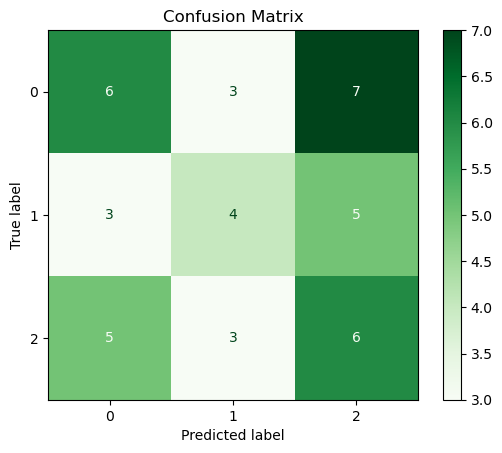


--- Precision-Recall Curves ---


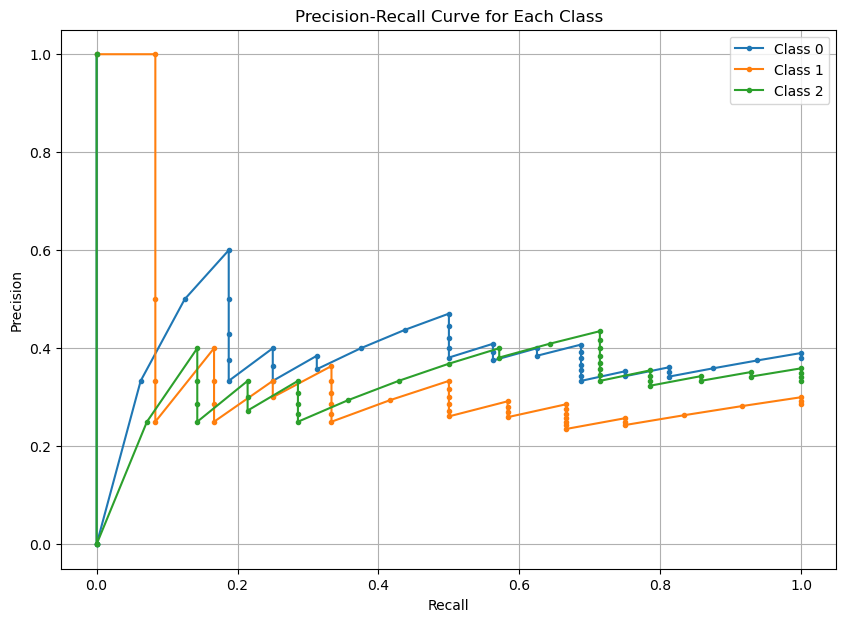

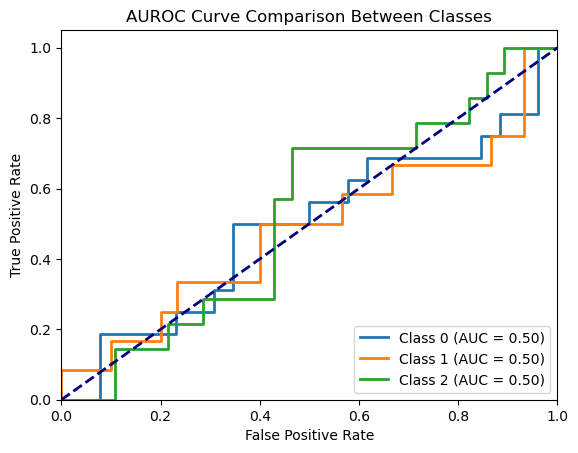

In [9]:

# --- 4. Perform Evaluation ---
print("\nEvaluating model on the test portion...")
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)

# --- 4a. Classification Report ---
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# --- 4b. Confusion Matrix ---
print("\n--- Confusion Matrix ---")
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

# --- 4c. Precision-Recall Curve ---
print("\n--- Precision-Recall Curves ---")
plt.figure(figsize=(10, 7))
for i in range(len(pipeline.classes_)):
    # Binarize the output
    y_true_bin = (y_test == pipeline.classes_[i]).astype(int)
    y_score = y_pred_proba[:, i]
    
    precision, recall, _ = precision_recall_curve(y_true_bin, y_score)
    plt.plot(recall, precision, marker='.', label=f'Class {pipeline.classes_[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class')
plt.legend()
plt.grid(True)
plt.show()

# --- 4d. AUROC ---
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Calculate the AUC - ROC score
roc_auc = roc_auc_score(y_test, y_pred_proba, average = 'weighted', multi_class='ovr')

# Compute ROC curve for each class
for i in range(pipeline.classes_.shape[0]):
	fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, i], pos_label=i)
	plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Curve Comparison Between Classes')
plt.legend(loc="lower right")
plt.show()


--- Class 0 ---
Threshold @ Recall ≥ 0.70: 0.1462
  Recall: 1.00, Precision: 0.38


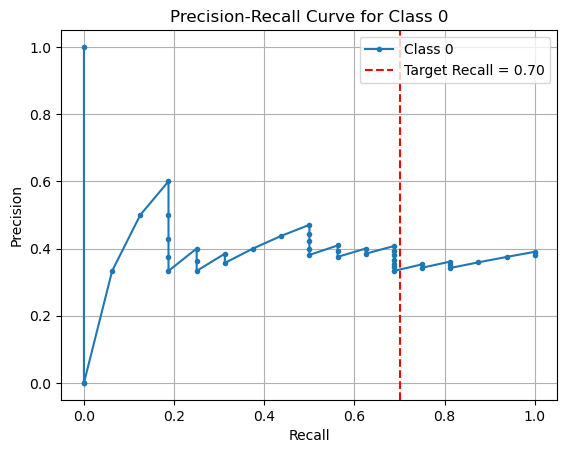


--- Class 1 ---
Threshold @ Recall ≥ 0.70: 0.1360
  Recall: 1.00, Precision: 0.29


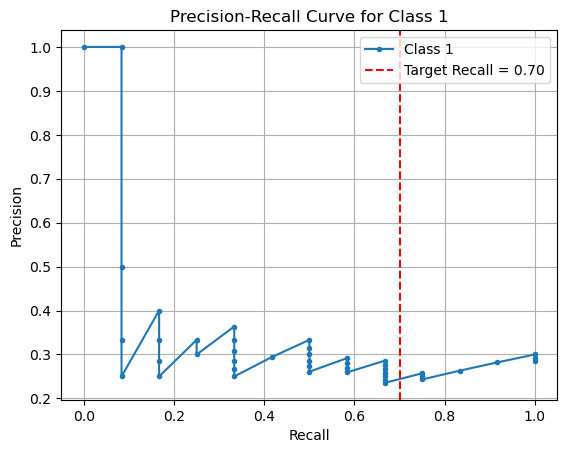


--- Class 2 ---
Threshold @ Recall ≥ 0.70: 0.0929
  Recall: 1.00, Precision: 0.33


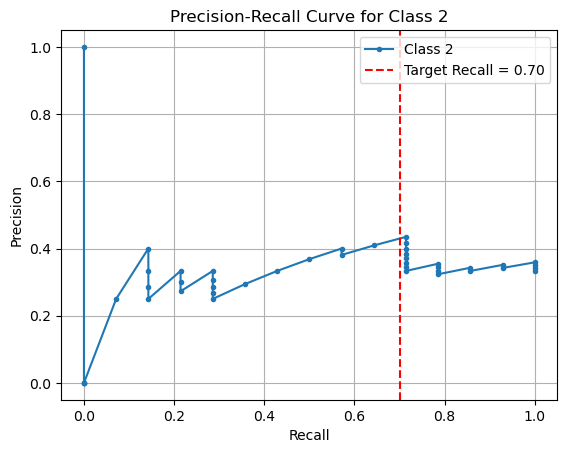


Selected thresholds per class:
Class 0: 0.14615436061872805
Class 1: 0.1359518009446814
Class 2: 0.09287749228798632


In [ ]:
# --- 4d. Precision and Recall vs. Threshold (for Surrogate Class 2) ---
desired_recall = 0.70
selected_thresholds = {}

# For each class (assuming classes 0, 1, 2)
classes = [0, 1, 2]

for cls in classes:
    print(f"\n--- Class {cls} ---")
    
    # Binary ground truth: 1 if current class, 0 otherwise
    y_true_bin = (y_test == cls).astype(int)
    
    # Predicted probability scores for the current class
    y_score = y_pred_proba[:, cls]
    
    # Compute precision-recall pairs
    precision, recall, thresholds = precision_recall_curve(y_true_bin, y_score)
    
    # precision_recall_curve gives (n_thresholds + 1) recall/precision points
    # thresholds has shape (n_thresholds,)
    
    # Find index where recall crosses desired_recall
    try:
        index = np.where(recall >= desired_recall)[0][0]
        
        if index >= len(thresholds):
            # Edge case: the last recall value doesn't have a corresponding threshold
            selected_threshold = thresholds[-1]
        else:
            selected_threshold = thresholds[index]
        
        selected_thresholds[cls] = selected_threshold
        print(f"Threshold @ Recall ≥ {desired_recall:.2f}: {selected_threshold:.4f}")
        print(f"  Recall: {recall[index]:.2f}, Precision: {precision[index]:.2f}")
        
    except IndexError:
        print(f"No threshold found for class {cls} reaching recall ≥ {desired_recall}")
        selected_thresholds[cls] = None
    
    # Plot the Precision-Recall curve
    plt.figure()
    plt.plot(recall, precision, marker='.', label=f'Class {cls}')
    plt.axvline(x=desired_recall, color='red', linestyle='--', label=f'Target Recall = {desired_recall:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for Class {cls}')
    plt.legend()
    plt.grid(True)
    plt.show()

print("\nSelected thresholds per class:")
for cls, thresh in selected_thresholds.items():
    print(f"Class {cls}: {thresh}")


In [12]:
class_counts = labelled_df['label'].value_counts().sort_index()

# Calculate the percentages
class_percentages = labelled_df['label'].value_counts(normalize=True).sort_index() * 100

print("--- Class Distribution of Labeled Data ---")
print("\nCounts:")
print(class_counts)
print("\nPercentages:")
print(class_percentages.round(2).astype(str) + '%')

--- Class Distribution of Labeled Data ---

Counts:
label
0    54
1    38
2    48
Name: count, dtype: int64

Percentages:
label
0    38.57%
1    27.14%
2    34.29%
Name: proportion, dtype: object
